**Lets starts with mounting the drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing all the necessary librtaries**

In [2]:
#Importing all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# **1. Data Understanding & Cleaning:**

**A. Read ‘vehicle.csv’ and save as DataFrame.**

In [3]:
#Loading CSV file

df = pd.read_csv('/content/drive/MyDrive/GL_AIML/UnsupervisedLearning/ProjectWork/Vehicle/vehicle.csv')

In [4]:
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [5]:
df.shape

(846, 19)

**B. Check percentage of missing values and impute with correct approach**

In [6]:
#Check for missing values

df.isnull().sum()

,0
compactness,0
circularity,5
distance_circularity,4
radius_ratio,6
pr.axis_aspect_ratio,2
max.length_aspect_ratio,0
scatter_ratio,1
elongatedness,1
pr.axis_rectangularity,3
max.length_rectangularity,0


In [8]:
missing_values = df.isnull().sum() / len(df) * 100
print("Percentage of missing values in each column:\n", missing_values)

Percentage of missing values in each column:
 compactness                    0.000000
circularity                    0.591017
distance_circularity           0.472813
radius_ratio                   0.709220
pr.axis_aspect_ratio           0.236407
max.length_aspect_ratio        0.000000
scatter_ratio                  0.118203
elongatedness                  0.118203
pr.axis_rectangularity         0.354610
max.length_rectangularity      0.000000
scaled_variance                0.354610
scaled_variance.1              0.236407
scaled_radius_of_gyration      0.236407
scaled_radius_of_gyration.1    0.472813
skewness_about                 0.709220
skewness_about.1               0.118203
skewness_about.2               0.118203
hollows_ratio                  0.000000
class                          0.000000
dtype: float64


As per output we can see there are many missing values that needs to be impute.

In [13]:
for column in df.select_dtypes(include=['number']):
    df[column].fillna(df[column].median(), inplace=True)

#Imputing the missing values with the median values for numeric columns only

In [15]:
#Checking for missing values again



df.isnull().sum() * 100

,0
compactness,0
circularity,0
distance_circularity,0
radius_ratio,0
pr.axis_aspect_ratio,0
max.length_aspect_ratio,0
scatter_ratio,0
elongatedness,0
pr.axis_rectangularity,0
max.length_rectangularity,0


As per result, there is no more missing values in any of the columns.

**C. Visualize a Pie-chart and print percentage of values for variable ‘class’.**

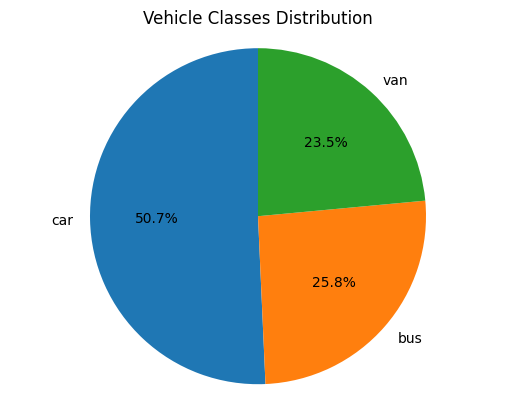

Percentage of values for variable 'class':
car: 50.7%
bus: 25.8%
van: 23.5%


In [23]:
#Pie Chart Visualization for variable 'class'

class_distribution = df['class'].value_counts()
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', startangle=90)
#plt.figure(figsize=(6,4))
plt.axis('equal')
plt.title('Vehicle Classes Distribution')
plt.show()

#Print percentage

#print("Percentage distribution of vehicle classes:\n", class_distribution / len(df) * 100)
class_percentages = class_distribution / len(df) * 100
print("Percentage of values for variable 'class':")
for class_name, percentage in class_percentages.items():
    print(f"{class_name}: {percentage:.1f}%")



**D. Check for duplicate rows in the data and impute with correct approach.**

In [24]:
#Checking for duplicate rows in the data

df.duplicated().sum()


0

As per result, data doesnot contain any duplicate rows.

# **2. Data Preparation:**

**A. Split data into X and Y.**

In [26]:
#Splitting data into X and Y

X = df.drop('class', axis = 1)
y = df['class']

**B. Standardize the Data.**

In [28]:
#Standardizing the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# **3. Model Building:**

**A. Train a base Classification model using SVM**

In [29]:
#Train a base SVM Model

svm_base = SVC()
svm_base.fit(X_scaled, y)


SVC()

**B. Print Classification metrics for train data.**

In [31]:
#Prediction on the training data
y_pred_train = svm_base.predict(X_scaled)

#Print Classification Metrics

print("Classification Report:\n", classification_report(y, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_train))
print("Accuracy Score:", accuracy_score(y, y_pred_train))

Classification Report:
               precision    recall  f1-score   support

         bus       0.99      0.98      0.98       218
         car       0.99      0.98      0.99       429
         van       0.95      0.98      0.97       199

    accuracy                           0.98       846
   macro avg       0.98      0.98      0.98       846
weighted avg       0.98      0.98      0.98       846

Confusion Matrix:
 [[214   0   4]
 [  2 421   6]
 [  1   3 195]]
Accuracy Score: 0.9810874704491725


**C. Apply PCA on the data with 10 components.**

In [32]:
#Applyting PCA on the data with 10 components
pca = PCA(n_components=10)
X_pca_10 = pca.fit_transform(X_scaled)

**D. Visualize Cumulative Variance Explained with Number of Components.**

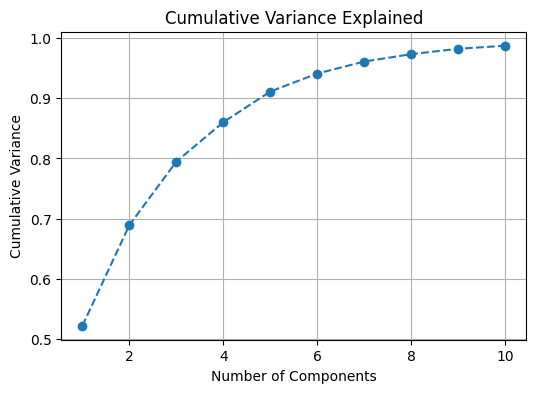

In [33]:
#Visualization of Cumulative Variance

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6, 4))
plt.plot(range(1,11), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Variance Explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.grid(True)
plt.show()

**E. Draw a horizontal line on the above plot to highlight the threshold of 90%.**

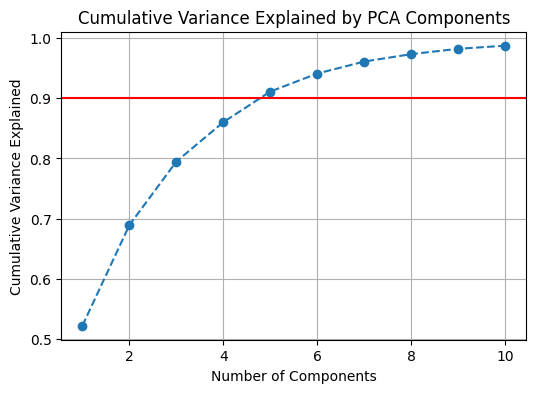

In [34]:
#Horizontal line for 90% variance

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='-')
plt.title('Cumulative Variance Explained by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()


**F. Apply PCA on the data. This time Select Minimum Components with 90% or above variance explained**

In [37]:
#Applying PCA

pca_90 = PCA(n_components=0.9)
X_pca_90 = pca_90.fit_transform(X_scaled)

print(f"Number of components selected: {pca_90.n_components_}")

Number of components selected: 5


**G. Train SVM model on components selected from above step**

In [38]:
#Train SVM Model on PCA Reduced data
svm_pca = SVC()
svm_pca.fit(X_pca_90, y)



SVC()

**H. Print Classification metrics for train data of above model and share insights.**

In [40]:
#Printing Classification Metrics for trained data with PCA Components

y_pred_pca_train = svm_pca.predict(X_pca_90)


#Print classification metrics

print("Classification Report (PCA):\n", classification_report(y, y_pred_pca_train))
print("Confusion Matrix (PCA):\n", confusion_matrix(y, y_pred_pca_train))
print("Accuracy Score (PCA):", accuracy_score(y, y_pred_pca_train))


Classification Report (PCA):
               precision    recall  f1-score   support

         bus       0.86      0.68      0.76       218
         car       0.84      0.89      0.87       429
         van       0.70      0.76      0.73       199

    accuracy                           0.81       846
   macro avg       0.80      0.78      0.78       846
weighted avg       0.81      0.81      0.81       846

Confusion Matrix (PCA):
 [[149  39  30]
 [ 10 383  36]
 [ 15  33 151]]
Accuracy Score (PCA): 0.8073286052009456


**Insights:**

Precision:
- First Model: Higher precision (bus: 0.99, car: 0.99, van: 0.95).
- PCA Model: Lower precision (bus: 0.86, car: 0.84, van: 0.70).
- The PCA model makes more incorrect positive predictions.

Recall:
- First Model: High recall across all classes (bus: 0.98, car: 0.98, van: 0.98).
- PCA Model: Lower recall, especially for the bus class (bus: 0.68).
-  The PCA model misses more actual positives, particularly for buses.

F1-Score:
- First Model: Higher F1-scores (bus: 0.98, car: 0.99, van: 0.97).
- PCA Model: Lower F1-scores (bus: 0.76, car: 0.87, van: 0.73).
- The PCA model has a less balanced performance.

Confusion Matrix:
- First Model: Fewer misclassifications (e.g., 4 misclassified buses).
- PCA Model: More misclassifications (e.g., 69 misclassified buses).
- PCA leads to more confusion between vehicle classes.

Accuracy:
- First Model: Higher accuracy (98.11%).
- PCA Model: Lower accuracy (80.73%).
- PCA results in a significant drop in overall accuracy.


. The first model outperforms the PCA-based model in all metrics.

. After applying PCA reduced the model's effectiveness, results in more misclassifications and lower accuracy.



# **4. Performance Improvement:**

**A. Train another SVM on the components out of PCA. Tune the parameters to improve performance.**

In [42]:
#Training SVM with parameter tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

#Defining the parameter grid

param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

#GridSearchCV imnplementation

svm_tuned = GridSearchCV(SVC(), param_grid, cv=5)
svm_tuned.fit(X_pca_90, y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']})

**B. Share best Parameters observed from above step.**

In [43]:
#Printing the best parameters
print("Best Parameters:", svm_tuned.best_params_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}


**C. Print Classification metrics for train data of above model and share relative improvement in performance in all the models along with insights.**

In [44]:
#Prediction on the training data with tuned model
y_pred_tuned_train = svm_tuned.predict(X_pca_90)

#Printing classification metrics
print("Classification Report (Tuned):\n", classification_report(y, y_pred_tuned_train))
print("Confusion Matrix (Tuned):\n", confusion_matrix(y, y_pred_tuned_train))
print("Accuracy Score (Tuned):", accuracy_score(y, y_pred_tuned_train))

Classification Report (Tuned):
               precision    recall  f1-score   support

         bus       0.85      0.83      0.84       218
         car       0.91      0.92      0.91       429
         van       0.81      0.82      0.81       199

    accuracy                           0.87       846
   macro avg       0.86      0.85      0.85       846
weighted avg       0.87      0.87      0.87       846

Confusion Matrix (Tuned):
 [[180  23  15]
 [ 13 393  23]
 [ 19  17 163]]
Accuracy Score (Tuned): 0.8699763593380615


**Performance metrics summary:**

1st Model:
- Accuracy: 98.11%
- Precision, Recall, F1-Score (Overall): High, around 0.98

PCA Model:
- Accuracy: 80.73%
- Precision, Recall, F1-Score (Overall): Lower than the original, around 0.80

Tuned Model:
- Accuracy: 86.99%
- Precision, Recall, F1-Score (Overall): Improved over PCA, but still below the original, around 0.87

**Improvements:**
PCA Model vs Tuned Model:

Accuracy:
- PCA: 80.73%
- Tuned: 86.99%
- Difference: +6.26%

**Insights:** The tuned model imporved from PCA Model but it is still below from the performance level of original model (1st model). This suggests that the tuning has improved performance but it has not fully recovered for the loss incurred by PCA.


Original Model vs Tuned Model:

Accuracy:
- Original: 98.11%
- Tuned: 86.99%
- Difference: -11.12%

**Insights:** The tuned model's accuracy is lower than the original model with significant value. This shows that the tuning helped but the overall performance is still significantly below than the original model.

**Insights in detail:**
- Impact of PCA: PCA's reduction in accuracy might have led to a loss of critical features. This can impact performance, if the original features had significant power.
- Impact of Tuning: After Tuning, we can see some improvement compare to PCA model but has not restored the performance to the original model's level.

Analysis of confusion Matrix:
- The original model got very high true positives and very low misclassifications across all the classes.
- PCA model shows lots of misclassifications, particularly for the 'bus' and 'van' classes.
- The tuned model shows less misclassifications than PCA, there are still possibilities of room for improvement.

We can conclude this with : Tuning has improved the PCA Model's performence. But the original model is still the moset effective.


# **5. Data Understanding & Cleaning:**

**A. Explain pre-requisite/assumptions of PCA.**

To apply PCA few prerequisites and assumptions must be considered:

- Data Scaling: PCA is sensitive to the scale of the data. Features should be standardized so that each feature contributes equally to the analysis.

Linearity:
- PCA assumes that the relationships between features are linear. It identifies principal components by calculating the directions of maximum variance in a linear space.

Mean-Centering:
- Data should be mean-centered

Correlation Among Features:
- PCA is most effective when there are correlations among features.

Now lets talk about assumptions:

Linear Relationships:
- PCA assumes that the data is best described by linear combinations of features.PCA may not perform well if the relationships in the data are nonlinear.

Variance:
- PCA assumes that the principal components are most important where the variance is highest.



To summerise these points we can say that:
- Data Scaling: Normalize data to ensure equal contribution from all features.
- Linearity: Assumes linear relationships among features.
- Mean-Centering: Subtract the mean from the data before applying PCA.
- Correlation: Works best when features are correlated.



**B. Explain advantages and limitations of PCA.**

Lets talk about Advantages of PCA firts:

- Reduces Dimensionality: PCA Simplifies the dataset by reducing the number of features, which can make analysis and visualization easier.

- Fast Computation: With less features, computational tasks like training models become fast.

- Removes Redundancy: Combines correlated features into principal components, reducing redundancy in the data.

- Enhances Visualization: PCA Makes it easier to visualize high-dimensional data by projecting it onto 2 or 3 principal components.



Limitations of PCA:
- Linear Assumptions: PCA assumes that linear relationships between features, and it may not capture complex patterns.
- Loss of Information: Reducing dimensions can lead to loss of important information, potentially affecting the quality of analysis. Exactly what we experienced with this dataset.


- Interpretability: Here Principal components can be difficult to interpret because they are combinations of original features.
- Sensitive to Scaling: PCA requires data to be standardized, otherwise features with larger scales can effect the results.